In [ ]:
# 1. Install correct PyTorch for Colab's CUDA 12.1
!pip install torch==2.4.0 --index-url https://lnkd.in/g_8dBghS

# 2. Uninstall any broken installs
!pip uninstall -y mamba-ssm causal-conv1d

# 3. Install Mamba using the PyTorch we just installed
!pip install causal-conv1d mamba-ssm --no-build-isolation

Looking in indexes: https://lnkd.in/g_8dBghS
ERROR: Could not find a version that satisfies the requirement torch==2.4.0 (from versions: none)
ERROR: No matching distribution found for torch==2.4.0
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 36.4 MB/s eta 0:00:00
  Created wheel for causal-conv1d: filename=causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl size=193835395 sha256=c16c1c48d4fa63415cc797e02d69f97

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from mamba_ssm import Mamba
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
df = pd.read_csv('btc_max_ohlc_yfinance.csv')

df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])

df.sort_values("date", axis=0, ascending=True, inplace=True)

# 篩選2021-07-01之後的資料
df = df[df['date'] >= '2021-07-01'].copy()

df = df.set_index('date')

In [ ]:
data = df.iloc[:, 3].values.reshape(-1, 1)

sc = MinMaxScaler()
data_scaled = sc.fit_transform(data)

length = 30
windows = []
target = []

# Window Slide
for i in range(len(data_scaled) - length):
    x = data_scaled[i : i + length]
    y = data_scaled[i + length]
    windows.append(x)
    target.append(y)

windows_scaled = np.array(windows)
target_scaled = np.array(target)

split_idx = int(len(windows_scaled) * 0.8)
X_train = windows_scaled[:split_idx]
y_train = target_scaled[:split_idx]
X_test = windows_scaled[split_idx:]
y_test = target_scaled[split_idx:]

# 轉成 Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
class TimeSeriesMamba(nn.Module):
    def __init__(self, input_dim=1, d_model=64, d_state=16, output_dim=1):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)

        # core
        self.mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=4,
            expand=2,
        )
        self.output_linear = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: (batch_size, 30, 1)
        x = self.input_linear(x)
        x = self.mamba(x)

        out = x[:, -1, :]
        out = self.output_linear(out)
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mamba_model = TimeSeriesMamba(input_dim=1, d_model=64, d_state=16, output_dim=1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mamba_model.parameters(), lr=0.0001)

epochs = 50

print("開始訓練 Mamba 模型...")
for epoch in range(epochs):
    mamba_model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = mamba_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

開始訓練 Mamba 模型...
Epoch [10/50], Loss: 0.000346
Epoch [20/50], Loss: 0.000218
Epoch [30/50], Loss: 0.000212
Epoch [40/50], Loss: 0.000206
Epoch [50/50], Loss: 0.000205


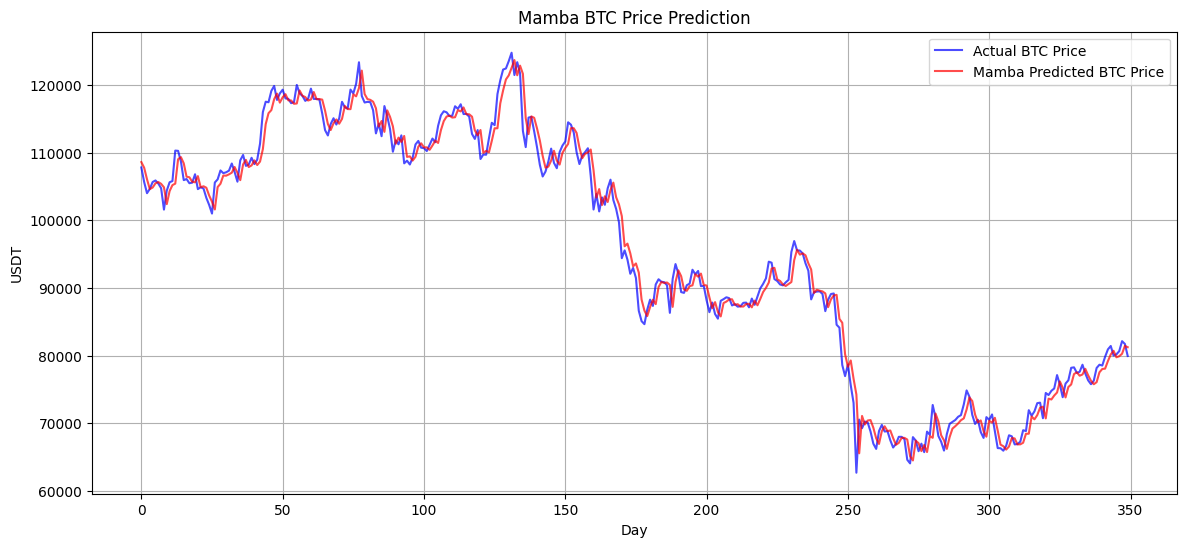

In [ ]:
mamba_model.eval()

with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    mamba_predictions = mamba_model(X_test_tensor)

mamba_predictions = mamba_predictions.cpu().numpy()
actuals = y_test_tensor.numpy()

mamba_predictions_real = sc.inverse_transform(mamba_predictions)
actuals_real = sc.inverse_transform(actuals)

plt.figure(figsize=(14, 6))
plt.plot(actuals_real, label='Actual BTC Price', color='blue', alpha=0.7)
plt.plot(mamba_predictions_real, label='Mamba Predicted BTC Price', color='red', alpha=0.7)

plt.title('Mamba BTC Price Prediction')
plt.xlabel('Day')
plt.ylabel('USDT')
plt.legend()
plt.grid(True)
plt.show()